# Replication: Jiang et al. (2024) — Table 1, Table A1, Figure A1

This notebook replicates the main quantitative results from:
> Jiang, E., Matvos, G., Piskorski, T., Seru, A. (2024). "Monetary Tightening
> and U.S. Bank Fragility in 2023: Mark-to-Market Losses and Uninsured Depositor
> Runs?" *Journal of Finance*.

**Methodology (Section II)**:
1. Take Q1 2022 balance sheet snapshot from WRDS Call Reports
2. Apply Q1 2022 → Q1 2023 ETF price changes to each bank's maturity-bucketed holdings
3. RMBS and first-lien mortgages use an RMBS multiplier = ΔMBS ETF / ΔTreasury Index
4. Treasury/other securities and other loans use direct Treasury ETF price changes
5. Aggregate by bank size category (Small, Large non-GSIB, GSIB)

In [1]:
import sys
sys.path.insert(0, "./src/")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from settings import config

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))
REPORT_DATE = config("REPORT_DATE")
MTM_END_DATE = config("MTM_END_DATE")

## Load Pre-Computed Results

`run_analysis.py` (or `doit`) computes all per-bank MTM losses and saves them
to `_data/`. We load those results here for analysis and presentation.

In [2]:
bank_losses = pd.read_parquet(DATA_DIR / "bank_losses.parquet")
uninsured_ratio = pd.read_parquet(DATA_DIR / "uninsured_ratio.parquet")
insured_coverage = pd.read_parquet(DATA_DIR / "insured_coverage.parquet")
table1 = pd.read_parquet(DATA_DIR / "table1.parquet")
table_a1 = pd.read_parquet(DATA_DIR / "table_a1.parquet")

print(f"Banks in sample: {len(bank_losses):,}")
print(f"Total MTM loss: ${-bank_losses['total_loss'].sum()/1e9:.1f}B")

Banks in sample: 4,845
Total MTM loss: $2.0B


## Table 1 Replication

**Paper targets** (Jiang et al. Table 1):
| Statistic | All Banks | Small | Large non-GSIB | GSIB |
|-----------|-----------|-------|----------------|------|
| Aggregate Loss | $2.2T | $146B | $623.2B | $1.4T |
| Median Loss/Assets | 9.2% | ... | ... | ... |
| Banks | 4,844 | ~4,000 | ~730 | 17 |

In [3]:
print("=" * 60)
print("TABLE 1: MTM Loss Summary by Bank Size Category")
print("=" * 60)
print(table1.to_string())

TABLE 1: MTM Loss Summary by Bank Size Category
                                   All Banks   Small  Large non-GSIB    GSIB
Aggregate Loss ($B)                   1964.9   122.0           841.2  1001.7
Median Bank Loss ($M)                   23.7    18.3           252.7  8849.5
Median Loss/Assets (%)                   7.5     7.4             7.7     4.1
Median Unins. Dep./MTM Assets (%)        0.0     0.0            33.9    38.5
Number of Banks                       4845.0  4096.0           732.0    17.0


In [4]:
# Compare to paper targets
paper_targets = {
    "All Banks": {"agg_loss_B": 2200, "n_banks": 4844},
    "Small": {"agg_loss_B": 146, "n_banks": 4095},
    "Large non-GSIB": {"agg_loss_B": 623, "n_banks": 732},
    "GSIB": {"agg_loss_B": 1400, "n_banks": 17},
}

print("\nComparison to paper targets:")
for group, targets in paper_targets.items():
    if group in table1.columns:
        our_loss = table1.loc["Aggregate Loss ($B)", group]
        our_n = table1.loc["Number of Banks", group]
        print(f"  {group}:")
        print(f"    Aggregate Loss: ${our_loss:.0f}B (paper: ${targets['agg_loss_B']}B)")
        print(f"    Banks: {our_n} (paper: {targets['n_banks']})")


Comparison to paper targets:
  All Banks:
    Aggregate Loss: $1965B (paper: $2200B)
    Banks: 4845.0 (paper: 4844)
  Small:
    Aggregate Loss: $122B (paper: $146B)
    Banks: 4096.0 (paper: 4095)
  Large non-GSIB:
    Aggregate Loss: $841B (paper: $623B)
    Banks: 732.0 (paper: 732)
  GSIB:
    Aggregate Loss: $1002B (paper: $1400B)
    Banks: 17.0 (paper: 17)


## Distribution of Loss/Asset Ratio

The loss-to-assets ratio characterizes how much each bank's asset value
would have declined if it marked all holdings to market as of Q1 2023.

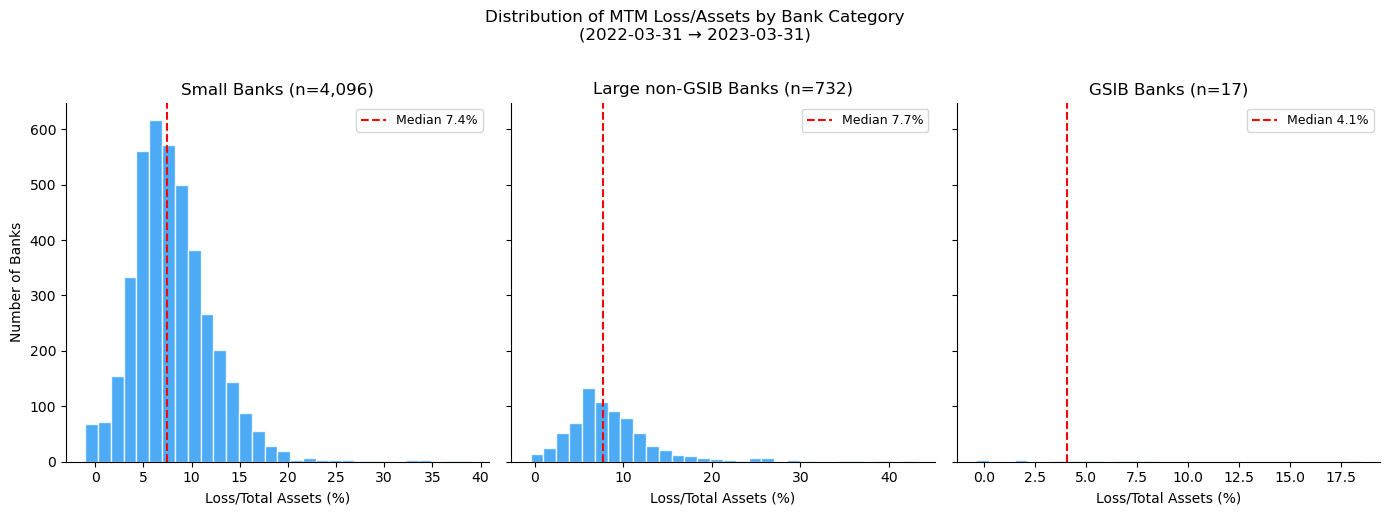

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, category in zip(axes, ["Small", "Large non-GSIB", "GSIB"]):
    mask = bank_losses["size_category"] == category
    subset = bank_losses.loc[mask, "loss_over_assets"].dropna() * 100
    ax.hist(subset, bins=30, color="#2196F3", edgecolor="white", alpha=0.8)
    ax.axvline(subset.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Median {subset.median():.1f}%")
    ax.set_xlabel("Loss/Total Assets (%)")
    ax.set_title(f"{category} Banks (n={mask.sum():,})")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Number of Banks")
plt.suptitle(f"Distribution of MTM Loss/Assets by Bank Category\n({REPORT_DATE} → {MTM_END_DATE})", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Table A1: Balance Sheet Composition

In [6]:
print("=" * 60)
print("TABLE A1: Balance Sheet Composition (Q1 2022, $billions)")
print("=" * 60)
print(table_a1.to_string())

TABLE A1: Balance Sheet Composition (Q1 2022, $billions)
size_category               Small  Large non-GSIB     GSIB    Total
RMBS                         84.9          1403.5   2006.9   3495.3
First-Lien Mortgages        214.7          1411.3   1317.8   2943.8
Treasury/Other Securities   228.4          1234.8   2784.1   4247.2
Other Loans                 646.9          2726.5     82.6   3456.0
Total Assets               1445.4         10842.1  11702.1  23989.6
Uninsured Deposits           66.2          4865.6   7053.9  11985.7
Insured Deposits            715.6          4759.3   5347.4  10822.2


## Figure A1: Aggregate Bank Balance Sheet

Stacked bar chart comparing book-value assets, MTM assets, and liabilities.

Saved: /Users/joewang/Desktop/MSFM_Courses/FINM32900/final_project/p08_jiang_et_al_2024/_output/figure_a1.pdf
Saved: /Users/joewang/Desktop/MSFM_Courses/FINM32900/final_project/p08_jiang_et_al_2024/_output/figure_a1.png


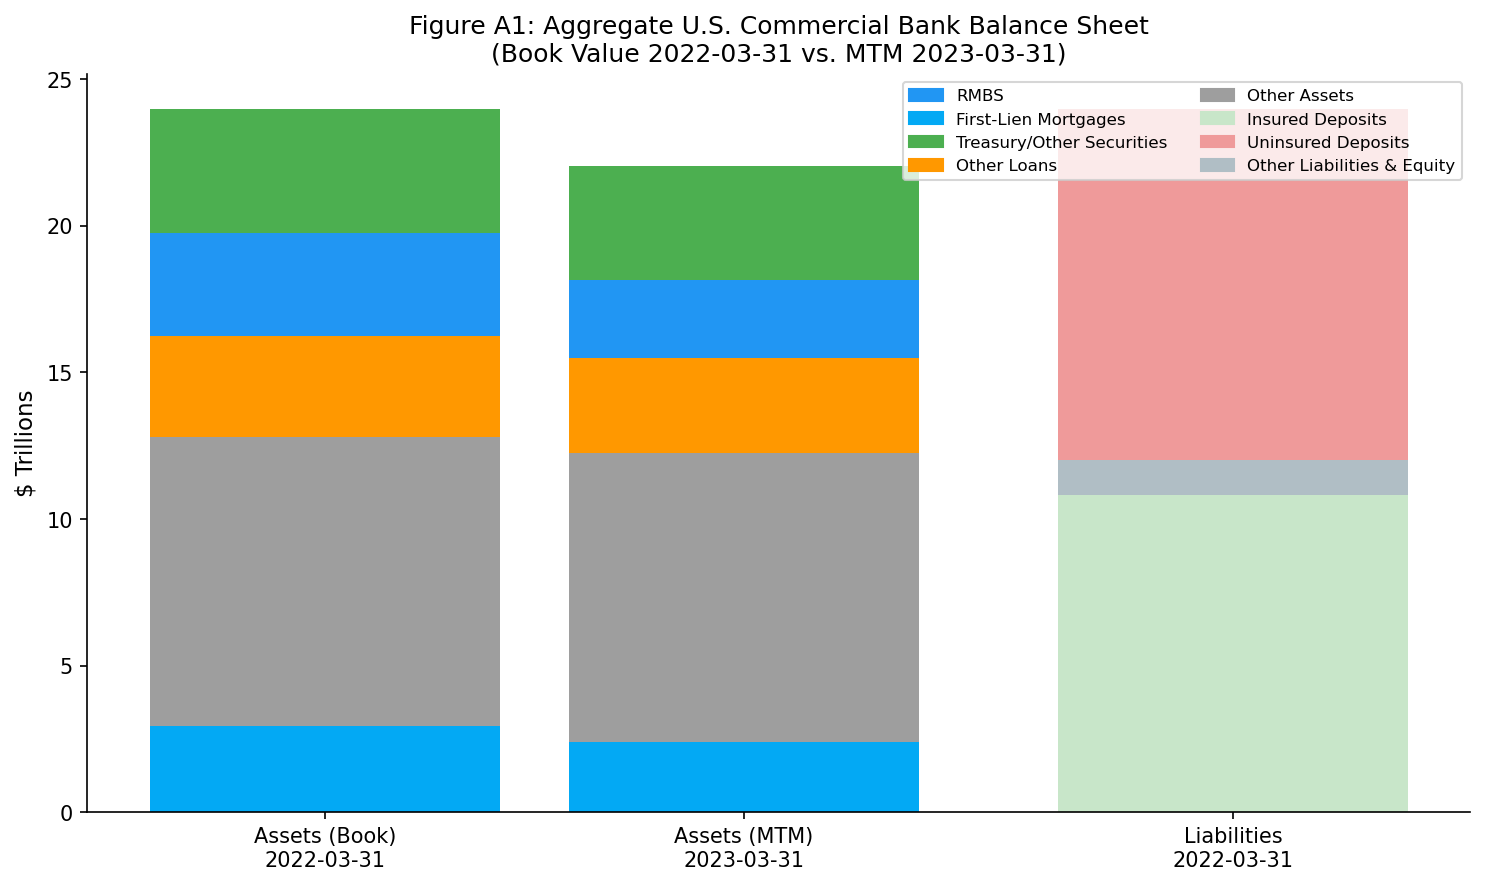

In [7]:
from create_figure_a1 import create_figure_a1
create_figure_a1()

# Display saved figure
from IPython.display import Image
Image(str(OUTPUT_DIR / "figure_a1.png"))

## Updated Replication with Most Recent Data

Below we recompute the analysis using the full date range from the `.env`
configuration (END_DATE in settings), allowing the user to see how the
MTM losses would look with the most recently available ETF prices.

In [8]:
import pull_wrds
import pull_etf_data
import clean_data
import calc_mtm_losses
import calc_table1

# Reload ETF data with full date range
etf_raw = pull_etf_data.load_etf_data()

# Get the most recent available quarter-end date
etf_quarters = etf_raw.resample("QE").first()
latest_date = str(etf_quarters.index[-1].date())
print(f"Most recent ETF quarter-end: {latest_date}")

Most recent ETF quarter-end: 2023-09-30


In [9]:
# Recompute with updated end date
rcon1 = pull_wrds.load_rcon_series_1()
rcon2 = pull_wrds.load_rcon_series_2()
rcfd1 = pull_wrds.load_rcfd_series_1()
rcfd2 = pull_wrds.load_rcfd_series_2()

rmbs = clean_data.get_rmbs(rcfd1, rcon1, rcon2, REPORT_DATE)
treasuries = clean_data.get_treasuries(rcfd2, rcon2, REPORT_DATE)
loans = clean_data.get_loans(rcon1, REPORT_DATE)
other_loans = clean_data.get_other_loans(rcon2, rcfd1, REPORT_DATE)
total_assets_updated = clean_data.get_total_assets(rcfd2, rcon2, REPORT_DATE)
total_assets_updated = calc_mtm_losses.classify_banks(total_assets_updated)
uninsured = clean_data.get_uninsured_deposits(rcon1, REPORT_DATE)
insured = clean_data.get_insured_deposits(rcon1, REPORT_DATE)

etf_q_updated = clean_data.clean_etf_prices(etf_raw, REPORT_DATE, latest_date)
price_changes_updated = calc_mtm_losses.calc_price_changes(etf_q_updated, REPORT_DATE, latest_date)
rmbs_mult_updated = calc_mtm_losses.calc_rmbs_multiplier(etf_q_updated, REPORT_DATE, latest_date)

bank_losses_updated = calc_mtm_losses.calc_bank_losses(
    rmbs, loans, treasuries, other_loans, total_assets_updated,
    price_changes_updated, rmbs_mult_updated,
)
uninsured_ratio_updated = calc_mtm_losses.calc_uninsured_deposit_ratio(uninsured, bank_losses_updated)
insured_cov_updated = calc_mtm_losses.calc_insured_deposit_coverage(insured, uninsured, bank_losses_updated)

table1_updated = calc_table1.calc_table1(bank_losses_updated, uninsured_ratio_updated, insured_cov_updated)

print(f"\nUpdated Table 1 ({REPORT_DATE} → {latest_date}):")
print(table1_updated.to_string())


Updated Table 1 (2022-03-31 → 2023-09-30):
                                   All Banks   Small  Large non-GSIB    GSIB
Aggregate Loss ($B)                   1782.7   108.4           752.6   921.6
Median Bank Loss ($M)                   20.5    16.0           223.4  8130.3
Median Loss/Assets (%)                   6.6     6.6             6.8     3.5
Median Unins. Dep./MTM Assets (%)        0.0     0.0            33.6    38.2
Number of Banks                       4845.0  4096.0           732.0    17.0
